## <h1><center>Course: Introduction to Machine Learning</center></h1>
## <h1><center># Homework 2 — Supervised Learning (100 pts)</center></h1>
### <h1><center>Important NOTE: In order to get full credit, for every question, you need to provide the details of your work on how to get to a solution or the end of a proof.</center></h1>
#### <h1><center>Instructor: Tan Bui-Thanh</center></h1>
#### <h1><center>TA: Venugopal Ranganathan</center></h1>
##### <h1><center>Due day: 11:59 pm, Tuesday, 16 September </center></h1>
#### <h1><center>All solutions must be in one pdf file except codes.</center><h1>


## Q1 (10 pts) — Feature Engineering on Diabetes


We practice feature engineering using the Diabetes dataset. This dataset has 10 input features; you'll create new features and examine correlations.

**Problem Tasks.**

1. (5 pts) Create a binary feature BMI_high: 1 if bmi > 0.05, else 0. Plot a histogram of BMI with the threshold marked.

2. (5 pts) Create an interaction feature `bp_x_s5 = bp * s5`. Plot `bp_x_s5` against the target variable and plot it.

3. (5 pts) Compute the Pearson correlation between BMI and the target.

4. (5 pts) In 2-3 sentences, explain why engineered features (e.g. thresholds or interactions) can help linear models capture more complex relationships.

Pearson correlation between 'bmi' and target: 0.586


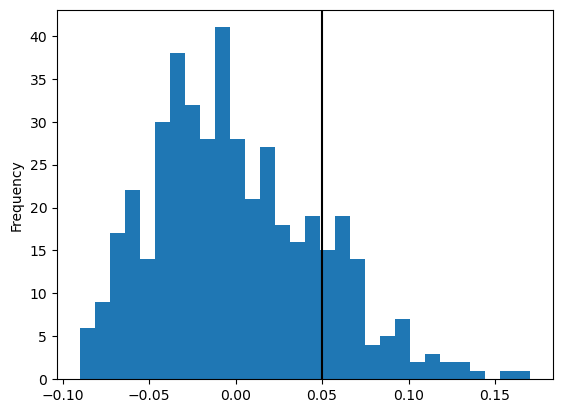

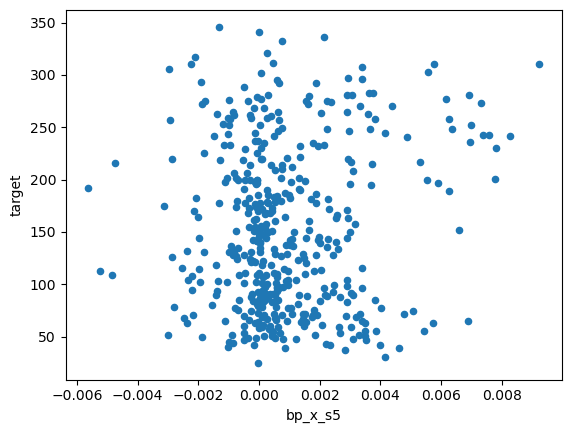

In [69]:
import pandas as pd
from sklearn import datasets
diabetes = datasets.load_diabetes()
X_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")


X_df['BMI_high'] = (X_df['bmi'] > .05).astype(int)
plot = X_df["bmi"].plot(kind='hist', bins=30)
plot.axvline(.05, color='black', linestyle = '-')

X_df['bp_x_s5'] = (X_df['bp'] * X_df['s5'])
X_temp = X_df.copy()
X_temp['target'] = y
plot2 = X_temp.plot(kind='scatter', x='bp_x_s5', y='target')

pearson_corr = X_df['bmi'].corr(y)
print(f"Pearson correlation between 'bmi' and target: {pearson_corr:.3f}")


3. The Pearson correlation between bmi and target is .586

4. Engineered features such as thresholds and interactions can help linear models capture more complex relationships such as real-world categories by defining a threshold, for example, categorizing low vs high BMI. Interactions can help models understand the joint effect of features on a target variable by statistically defining the relationship.


## Q2 (15 pts) - Polynomial Regression & Hold-out MSE

We studied underfitting, overfitting, and good generalization using polynomial regression. Train models of degree 1, 12, and 5, and evaluate them on a hold-out set.

**Problem Tasks:**

1. (8 pts) In one figure with 3 subplots, fit degrees 1, 12, and 5. Label them as underfit, overfit, or good fit.

2. (8 pts) Compute the hold-out mean squared error (MSE) for each degree and display it on the subplot.

3. (9 pts) In 5-8 sentences, interpret the results: How do model complexity and generalization (predictive accuracy) trade off?


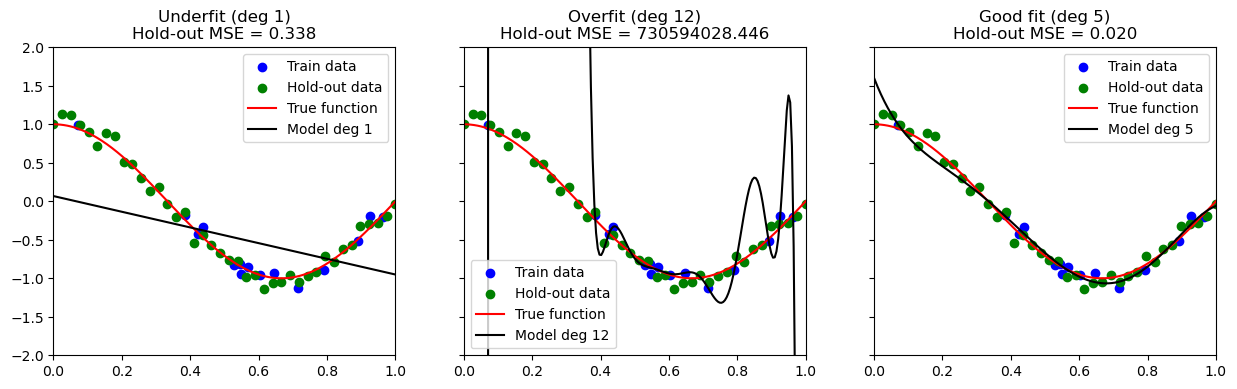

In [71]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(0)
def true_fn(x): return np.cos(1.5*np.pi*x)


# train data to fit models on
X=np.sort(np.random.rand(15));
y=true_fn(X)+0.1*np.random.randn(15)

# hold out dataset to make predictions on
Xh=np.linspace(0,1,40);
yh=true_fn(Xh)+0.1*np.random.randn(40)

degrees = [1, 12, 5]

# large set of x-values to visualize the fitted model and the true function.
xx = np.linspace(0, 1, 200)

labels = ["Underfit (deg 1)", "Overfit (deg 12)", "Good fit (deg 5)"]
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, (deg, label) in enumerate(zip(degrees, labels)):
    X_train = X.reshape(-1, 1)
    Xh_reshaped = Xh.reshape(-1, 1)
    xx_reshaped = xx.reshape(-1, 1)

    poly = PolynomialFeatures(degree=deg)
    X_poly = poly.fit_transform(X_train)
    Xh_poly = poly.transform(Xh_reshaped)
    xx_poly = poly.transform(xx_reshaped)

    model = LinearRegression().fit(X_poly, y)

    y_plot = model.predict(xx_poly)
    y_pred_holdout = model.predict(Xh_poly)

    mse = mean_squared_error(yh, y_pred_holdout)

    axs[i].scatter(X, y, color="blue", label="Train data")
    axs[i].scatter(Xh, yh, color="green", label="Hold-out data")
    axs[i].plot(xx, true_fn(xx), color="red", linestyle="-", label="True function")
    axs[i].plot(xx, y_plot, color="black", label=f"Model deg {deg}")
    axs[i].set_title(f"{label}\nHold-out MSE = {mse:.3f}")
    axs[i].set_ylim(-2,2)
    axs[i].set_xlim(0,1)
    axs[i].legend()

3. Polynomial degrees(1,5,12) control the model's complexity. Low degrees are underfit and high degree polynomials overfit the train data and perform poorly on unseen data. The degree 1 model ignores the true function as it is a straight line and performs poorly in terms of estimating points thus the poor MSE. The model of degree 12 essentially memorizes the training data and thus fails to generalize giving it a much higher error on the hold-out set. The model with a degree of 5 performs the best as we can tell by the low MSE. Furthermore, in the plot, we can see that is captures the true function trend despite the noisy data. The main takeaway from this is the bias-variance tradeoff. When the model is too simple, the bias is high, and when its too complex, the variance is high. In between this somewhere, we have good generalization, which depends on the data, where the model's complexity is just right to make accurate predictions and minimize variance. 

## Q3 (15 pts) — Ridge (L2) vs Lasso (L1) on Diabetes

We compare compare Ridge and Lasso regression as regularization strength α varies, and then evaluate test-set performance.

**Problem Tasks:**

1. (8 pts) Plot coefficient paths for Ridge and Lasso across a grid of α values (log-scaled x-axis). Use side-by-side subplots.

2. (6 pts) In 3-5 sentences, explain why Lasso tends to produce sparse solutions (some coefficients exactly 0), while Ridge does not.

3. (6 pts) Pick a reasonable $\alpha$ for Ridge and Lasso each (justify briefly), fit on a 70/30 train/test split, and report the test MSE for both.



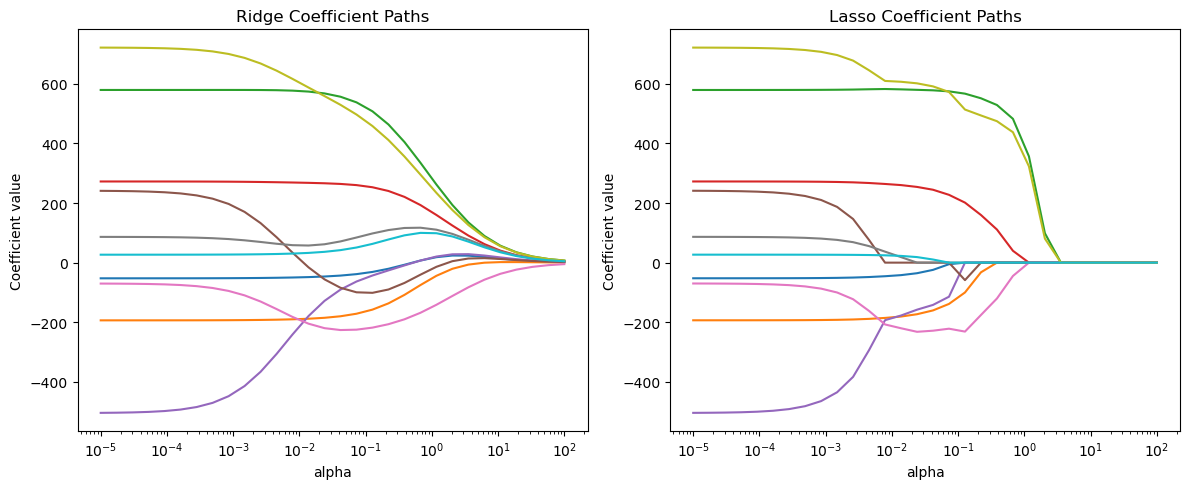

Best α (Ridge): 0.04175318936560404  Test MSE: 3085.274961892412
Best α (Lasso): 0.07278953843983153  Test MSE: 3115.1454408371715


In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load Diabetes dataset
X_d, y_d = load_diabetes(return_X_y=True)

# Candidate alphas (regularization strengths)
alphas = np.logspace(-5, 2, 30)

# Train - test split
Xtr, Xte, ytr, yte = train_test_split(X_d, y_d, test_size=0.3, random_state=0)


ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a, fit_intercept=True).fit(Xtr, ytr)
    lasso = Lasso(alpha=a, max_iter=10000).fit(Xtr, ytr)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i in range(X_d.shape[1]):
    axs[0].plot(alphas, ridge_coefs[:, i])
axs[0].set_xscale('log')
axs[0].set_xlabel('alpha')
axs[0].set_ylabel('Coefficient value')
axs[0].set_title('Ridge Coefficient Paths')

for i in range(X_d.shape[1]):
    axs[1].plot(alphas, lasso_coefs[:, i])
axs[1].set_xscale('log')
axs[1].set_xlabel('alpha')
axs[1].set_ylabel('Coefficient value')
axs[1].set_title('Lasso Coefficient Paths')

plt.tight_layout()
plt.show()

ridge_cv = RidgeCV(alphas=alphas).fit(Xtr, ytr)
lasso_cv = LassoCV(alphas=alphas).fit(Xtr, ytr)

best_alpha_ridge = ridge_cv.alpha_
best_alpha_lasso = lasso_cv.alpha_

ridge_best = Ridge(alpha=best_alpha_ridge).fit(Xtr, ytr)
lasso_best = Lasso(alpha=best_alpha_lasso).fit(Xtr, ytr)

ridge_mse = mean_squared_error(yte, ridge_best.predict(Xte))
lasso_mse = mean_squared_error(yte, lasso_best.predict(Xte))

print("Best α (Ridge):", best_alpha_ridge, " Test MSE:", ridge_mse)
print("Best α (Lasso):", best_alpha_lasso, " Test MSE:", lasso_mse)


2. Lasso tends to produce sparse solutions while ridge does not because Ridge uses an L2 penalty which shrinks the regression coefficients in the direction of 0 but not 0 itself. As we visualized in class, the constraint region is a sphere so the smooth shape doesn't mark the axis. Lasso uses an L1 penalty and we saw the constraint region was a rhombus with sharp corners that touch the axis. When the loss function's edge touches the corner, one, possibly more, coefficients become exactly 0. As a result, both techniques can shrink but only Lasso can perform variable selection at the same time leading to sparse results. 

3. The alpha value for is chosen through cross-validation. We know the best alpha values are picked because they will produce the least test MSE without over-shrinking for Ridge and ensuring proper variable selection(sparsity) and performance for Lasso. The $\alpha$ and test MSE for Ridge are 0.0418 and 3085.3 for Ridge respectively. The $\alpha$ and test MSE for Lasso are 0.0728 and 3115.2 respectively. 

## Q4 (60 pts) (Linear regression + regularization techniques + data augmentation)

In this problem, we approximate the polynomial from noisy data points. To that end, we generate a data pair $(x^{(i)}, y^{(i)})$ from the following noise-corrupted relation  
$$
f(x^{(i)}) = 0.5 - {x^{(i)}} - 0.5 [{x^{(i)}}]^2 - 2 [{x^{(i)}}]^3 + 5 [{x^{(i)}}]^4
$$
$$ y^{(i)} = f(x^{(i)}) + \delta \varphi^{(i)} f(x^{(i)})$$
of the following  ground truth function
$$ y = 0.5 - {x} - 0.5 {x}^2 - 2 {x}^3 + 5 {x}^4$$

where $\delta = 0.05$ is the noise level, $\varphi^{(i)}$ is drawn from standard normal distribution (given in the pseudo-code). We need to generate 8 holdout samples and 7 training samples.

- (1.a) (+10) Fill the generating data code and produce figures to visualize data and true functions.
- (1.b) (+10) Perform the LinearRegression() using polynomial approximation of order of 1, 10 and 4. Visualizing each cases to see which case are overfitting, underfitting, and fitting well. Present the mean square error of the holdout data to support your observation.
- (1.c) (+10) For the overfitting senario, apply L2 regularization. You need to do:
    + step 1: Plot the L2 regularization model, no regularization model, and the ground truth function in one plot to see how L2 impacts the fit (pick a reasonable $\lambda$).
    + step 2: Plot the mean square error of holdout data as a function of the regularization parameter $\lambda$ over the range $\lambda \in [10^{-5},10]$. What is the optimal $\lambda$ approximately?
    + step 3: Using L-curved technique (read [https://www.sintef.no/globalassets/project/evitameeting/2005/lcurve.pdf]) to find out the optimal $\lambda$. The L-curved line is the one represents the relationship between residual norm $||y - f(x,\boldsymbol{\theta})||_2$ and solution norm $||\boldsymbol{\theta}||_2$. Plot the L-curve and compare the optimal values of $\lambda$ from step 2 and step 3?
- (1.d) (+10) For the overfitting senario, apply L1 regularization. Repeat the all 3 steps in the question (1.c).
- (1.e) (+10) For the overfitting senario, apply Elasticnet regularization (a mixture of L1 and L2), i.e., the loss function with Elasticnet regularization is
$$ J(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^n L(y^{(i)}, \boldsymbol{\theta}^\top \boldsymbol{\Phi}(x^{(i)})) + \lambda \cdot ||\boldsymbol{\theta}||_1 + \frac{1}{2} \gamma ||\boldsymbol{\theta}||_2^2$$

We are interested in the performance of the mean square error of the holdout data as a function of $\lambda$ and $\gamma$. One way to visualize this is to plot the contour of the mean square error of the holdout data as a function of $\lambda$ and $\gamma$. Plot the contour and discuss the relationship between Elasticnet and L2, L1 regularization?

- (1.g) (+10) **Can we do something else** and yet achieve the same regularization effect? One way to accomplish this is via **data augmentation techniques**. The data augmentation technique that we will attempt consists of 4 steps:
    + step 1: Clone 7 training data samples (X in the code) into 350 samples (using numpy.repeat). (Note: this is noise-free data).
    + step 2: We add noise to these 350 samples by $$\tilde{x}^i = x^i + \delta \varphi^i,$$ where $\varphi^i$ is drawn from standard normal distribution. This is our augmented data, called X_data_augmented.
    + step 3: Similarly, clone the 7 training labels data, corresponding to the cloned X data, into 350 samples (using numpy.repeat), denoted y_data_augmented.
    + step 4: Now, we have (X_data_augmented, y_data_augmented) pairs. Use LinearRegression to train the model from these augmented data pairs.

    You need to (1) generate augmented data, (2) Determine a good noise level $\delta$ by trying different values of $\delta$? Explain why too much or too small noise is not good? To answer the last question, you may need to read the folllowing references
    1. Train Neural Networks With Noise to Reduce Overfitting, [https://machinelearningmastery.com/train-neural-networks-with-noise-to-reduce-overfitting/]
    2. [https://arxiv.org/abs/2208.04995]

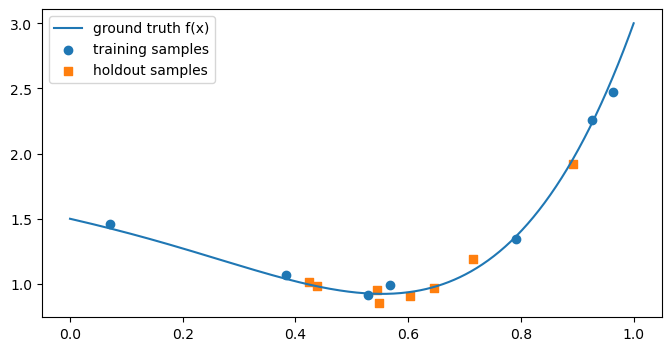

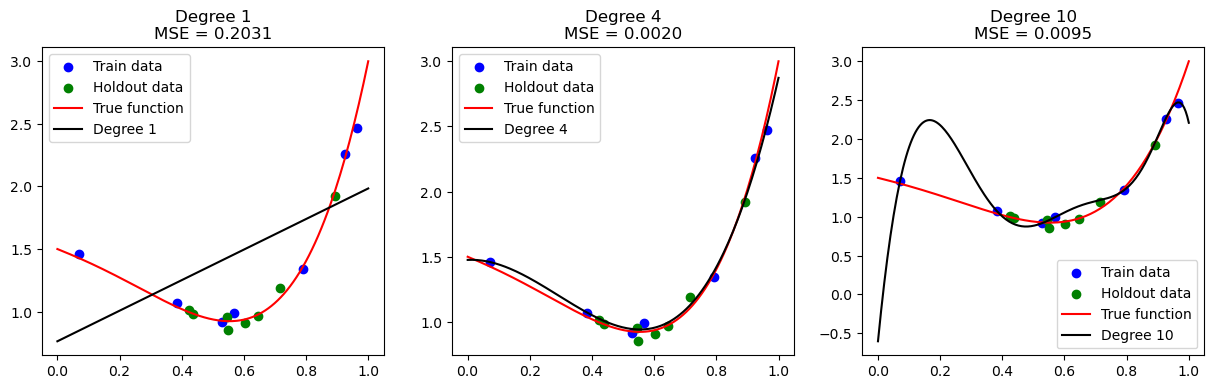

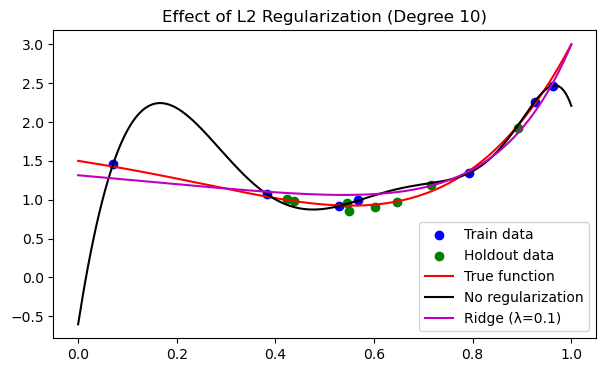

Step 2: Optimal λ from holdout MSE ≈ 4.32876e-04, MSE = 0.002309


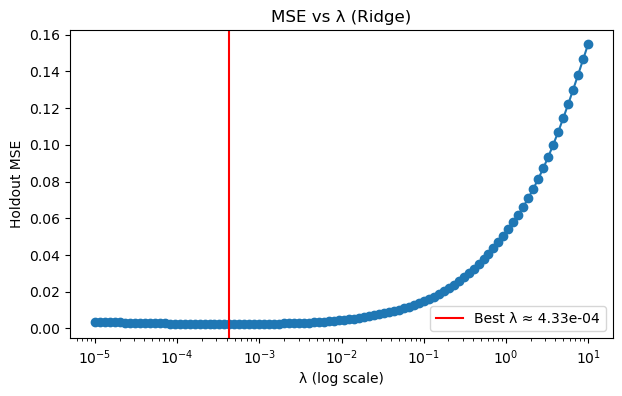

Step 3: Optimal λ from L-curve ≈ 2.31013e-03


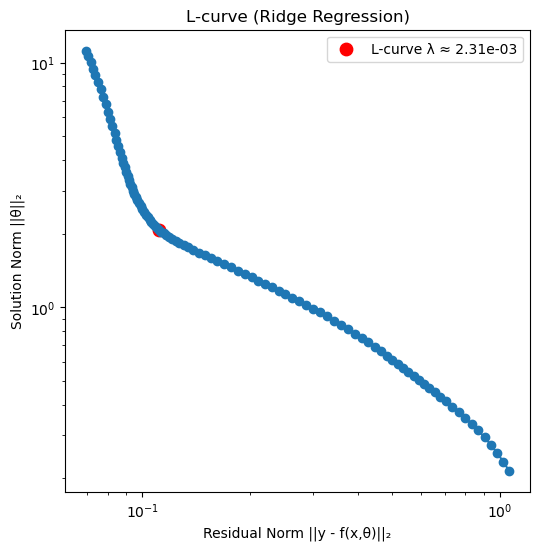

Comparison: Holdout MSE λ ≈ 4.33e-04, L-curve λ ≈ 2.31e-03


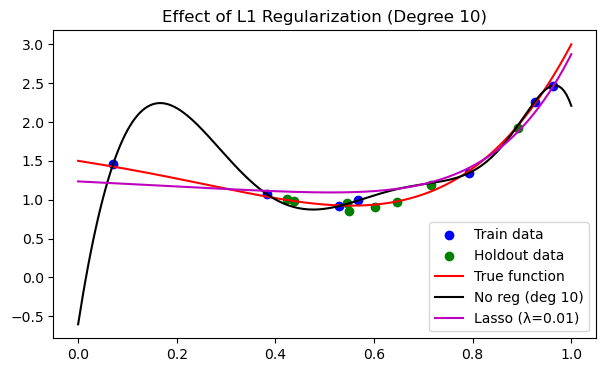

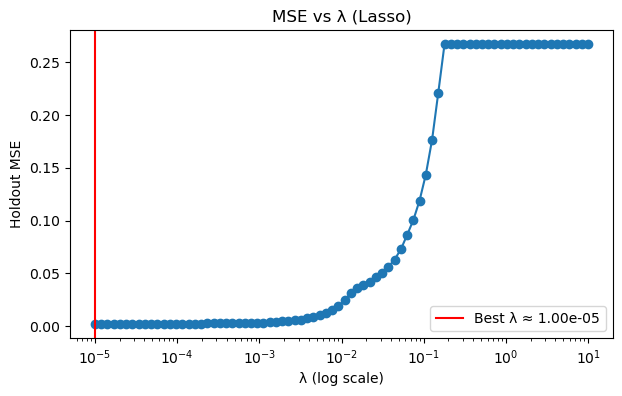

Step 2 (Lasso): Best λ from holdout MSE ≈ 1.00e-05, MSE = 0.002096


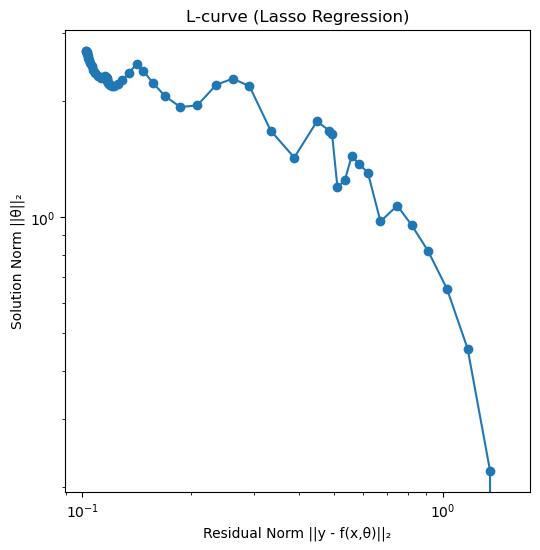

Step 3 (Lasso): Approx L-curve λ ≈ 9.16e-03
Comparison: Holdout-optimal λ ≈ 1.00e-05, L-curve λ ≈ 9.16e-03
ElasticNet best λ ≈ 6.81e-05, γ ≈ 1.00e-05, MSE = 0.002276


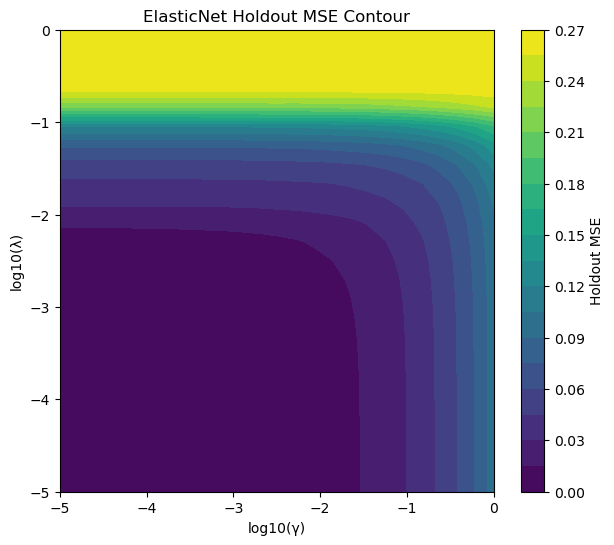

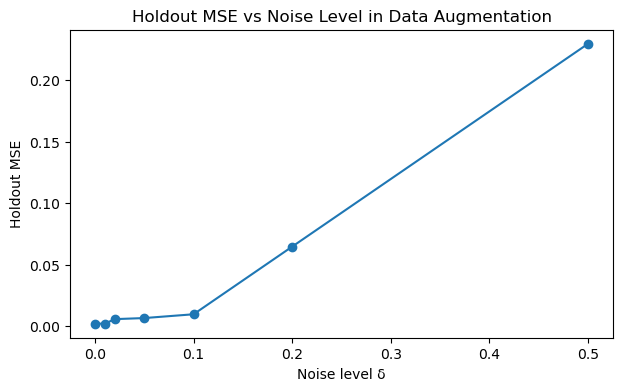

Best δ = 0.01, MSE = 0.001778
Baseline deg10 no-regularization MSE ≈ 0.009490


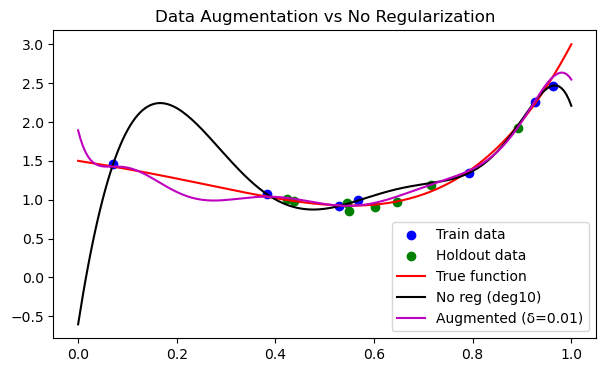

In [103]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 4]

import pandas as pd
from sklearn import datasets
np.random.seed(0)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, Lasso, LogisticRegression

## please keep the below codes for generating x, DO NOT CHANGE!

order_true = 5
true_coefficient = np.array([.5, -1, -.5, -2, 5])

def true_fn(X):
    f = np.ones((X.shape))
    for i in range(order_true):
        f += true_coefficient[i] * X**i
    return f

# ==========================================================================================
# holdout samples
n_holdout_samples = 8
X_holdout = np.sort(np.random.rand(n_holdout_samples))

# Training samples
n_samples = 7
X_train = np.sort(np.random.rand(n_samples))
# ==========================================================================================

def generate_noisy_y(X,):
    f = true_fn(X)
    delta=0.05
    phi = np.random.randn(*np.shape(X))
    return f + delta * phi * f

# generate labels
y_train = generate_noisy_y(X_train)
y_holdout = generate_noisy_y(X_holdout)
# plotting grid
X_grid = np.linspace(0, 1, 400)
y_true_grid = true_fn(X_grid)
plt.figure()
plt.plot(X_grid, y_true_grid, label='ground truth f(x)')
plt.scatter(X_train, y_train, marker='o', label='training samples')
plt.scatter(X_holdout, y_holdout, marker='s', label='holdout samples')
plt.legend()
plt.show()

# ==========================================================================================
# Fit polynomial regression models with different orders
degrees = [1, 4, 10]
mse_values = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, deg in enumerate(degrees):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    model.fit(X_train.reshape(-1, 1), y_train)
    X_plot = np.linspace(0, 1, 200)
    y_pred = model.predict(X_plot.reshape(-1, 1))
    y_holdout_pred = model.predict(X_holdout.reshape(-1, 1))

    mse = np.mean((y_holdout - y_holdout_pred) ** 2)
    mse_values.append(mse)
    
    axes[idx].scatter(X_train, y_train, color="blue", label="Train data")
    axes[idx].scatter(X_holdout, y_holdout, color="green", label="Holdout data")
    axes[idx].plot(X_plot, true_fn(X_plot), color = "red", label="True function")
    axes[idx].plot(X_plot, y_pred, color = "black", label=f"Degree {deg}")
    axes[idx].set_title(f"Degree {deg}\nMSE = {mse:.4f}")
    axes[idx].legend()

#=========================================================================================
# 1c. Ridge Regression
degree_overfit = 10
alphas = np.logspace(-5, 1, 100) 
poly = PolynomialFeatures(degree=degree_overfit, include_bias=False)
X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
X_holdout_poly = poly.transform(X_holdout.reshape(-1, 1))
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)

# Step 1: Compare Ridge vs No Regularization
linreg = LinearRegression().fit(X_train_poly, y_train)
y_pred_lin = linreg.predict(X_plot_poly)

ridge_example = Ridge(alpha=0.1).fit(X_train_poly, y_train)
y_pred_ridge = ridge_example.predict(X_plot_poly)

plt.figure(figsize=(7, 4))
plt.scatter(X_train, y_train, color="blue", label="Train data")
plt.scatter(X_holdout, y_holdout, color="green", label="Holdout data")
plt.plot(X_plot, true_fn(X_plot), color = "red", label="True function")
plt.plot(X_plot, y_pred_lin, "black", label="No regularization")
plt.plot(X_plot, y_pred_ridge, "m-", label="Ridge (λ=0.1)")
plt.title("Effect of L2 Regularization (Degree 10)")
plt.legend()
plt.show()

# Step 2: MSE vs λ
mse_ridge, models = [], []
for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train_poly, y_train)
    y_holdout_pred = ridge.predict(X_holdout_poly)
    mse_ridge.append(np.mean((y_holdout - y_holdout_pred) ** 2))
    models.append(ridge)

optimal_idx = np.argmin(mse_ridge)
optimal_lambda_mse = alphas[optimal_idx]
print(f"Step 2: Optimal λ from holdout MSE ≈ {optimal_lambda_mse:.5e}, MSE = {mse_ridge[optimal_idx]:.6f}")

plt.figure(figsize=(7, 4))
plt.semilogx(alphas, mse_ridge, marker="o")
plt.axvline(optimal_lambda_mse, color="r", linestyle="-", label=f"Best λ ≈ {optimal_lambda_mse:.2e}")
plt.xlabel("λ (log scale)")
plt.ylabel("Holdout MSE")
plt.title("MSE vs λ (Ridge)")
plt.legend()
plt.show()

# Step 3: L-curve
residual_norms, solution_norms = [], []
for ridge in models:
    y_pred_train = ridge.predict(X_train_poly)
    residual_norms.append(np.linalg.norm(y_train - y_pred_train, 2))
    solution_norms.append(np.linalg.norm(ridge.coef_, 2))

residual_norms, solution_norms = np.array(residual_norms), np.array(solution_norms)
log_r, log_s = np.log(residual_norms), np.log(solution_norms)
d_log_r = np.gradient(log_r, np.log(alphas))
d_log_s = np.gradient(log_s, np.log(alphas))
d2_log_r = np.gradient(d_log_r, np.log(alphas))
d2_log_s = np.gradient(d_log_s, np.log(alphas))

curvature = 2 * (d_log_r * d2_log_s - d2_log_r * d_log_s) / ((d_log_r**2 + d_log_s**2) ** 1.5)
lambda_lcurve = alphas[np.argmax(curvature)]
print(f"Step 3: Optimal λ from L-curve ≈ {lambda_lcurve:.5e}")


plt.figure(figsize=(6, 6))
plt.loglog(residual_norms, solution_norms, marker="o")
plt.scatter(residual_norms[np.argmax(curvature)], solution_norms[np.argmax(curvature)], color="r", s=80, label=f"L-curve λ ≈ {lambda_lcurve:.2e}")
plt.xlabel("Residual Norm ||y - f(x,θ)||₂")
plt.ylabel("Solution Norm ||θ||₂")
plt.title("L-curve (Ridge Regression)")
plt.legend()
plt.show()

# Final comparison
print(f"Comparison: Holdout MSE λ ≈ {optimal_lambda_mse:.2e}, "
      f"L-curve λ ≈ {lambda_lcurve:.2e}")

#=========================================================================================
# 1d. Lasso 
degree_overfit = 10
alphas_l1 = np.logspace(-5, 1, 80)
poly = PolynomialFeatures(degree=degree_overfit, include_bias=False)
X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
X_holdout_poly = poly.transform(X_holdout.reshape(-1, 1))
X_plot_poly = poly.transform(X_plot)

lasso_example = Lasso(alpha=0.01, max_iter=10000).fit(X_train_poly, y_train)
y_pred_lasso = lasso_example.predict(X_plot_poly)

plt.figure(figsize=(7, 4))
plt.scatter(X_train, y_train, color="blue", label="Train data")
plt.scatter(X_holdout, y_holdout, color="green", label="Holdout data")
plt.plot(X_plot, true_fn(X_plot), color = "red", label="True function")
plt.plot(X_plot, linreg.predict(X_plot_poly), color="black", label="No reg (deg 10)")
plt.plot(X_plot, y_pred_lasso, "m-", label="Lasso (λ=0.01)")
plt.title("Effect of L1 Regularization (Degree 10)")
plt.legend()
plt.show()

mse_lasso, models_l1 = [], []
for a in alphas_l1:
    lasso = Lasso(alpha=a).fit(X_train_poly, y_train)
    y_holdout_pred = lasso.predict(X_holdout_poly)
    mse_lasso.append(mean_squared_error(y_holdout, y_holdout_pred))
    models_l1.append(lasso)

mse_lasso = np.array(mse_lasso)
best_idx_l1 = np.argmin(mse_lasso)
best_lambda_l1 = alphas_l1[best_idx_l1]

plt.figure(figsize=(7, 4))
plt.semilogx(alphas_l1, mse_lasso, marker="o")
plt.axvline(best_lambda_l1, color="r", linestyle="-", label=f"Best λ ≈ {best_lambda_l1:.2e}")
plt.xlabel("λ (log scale)")
plt.ylabel("Holdout MSE")
plt.title("MSE vs λ (Lasso)")
plt.legend()
plt.show()
print(f"Step 2 (Lasso): Best λ from holdout MSE ≈ {best_lambda_l1:.2e}, MSE = {mse_lasso[best_idx_l1]:.6f}")

# Step 3: L-curve (Residual vs Solution norm)
residual_norms_l1, solution_norms_l1 = [], []
for lasso in models_l1:
    y_pred_train = lasso.predict(X_train_poly)
    residual_norms_l1.append(np.linalg.norm(y_train - y_pred_train, 2))
    solution_norms_l1.append(np.linalg.norm(lasso.coef_, 2))

residual_norms_l1 = np.array(residual_norms_l1)
solution_norms_l1 = np.array(solution_norms_l1)

plt.figure(figsize=(6, 6))
plt.loglog(residual_norms_l1, solution_norms_l1, marker="o")
plt.xlabel("Residual Norm ||y - f(x,θ)||₂")
plt.ylabel("Solution Norm ||θ||₂")
plt.title("L-curve (Lasso Regression)")
plt.show()

lambda_lcurve_l1 = alphas_l1[np.argmax(solution_norms_l1 < np.median(solution_norms_l1))]
print(f"Step 3 (Lasso): Approx L-curve λ ≈ {lambda_lcurve_l1:.2e}")
print(f"Comparison: Holdout-optimal λ ≈ {best_lambda_l1:.2e}, L-curve λ ≈ {lambda_lcurve_l1:.2e}")

#=========================================================================================
# 1e. Elasticnet Regularization
lambdas_en = np.logspace(-5, 0, 25)   # L1 weights
gammas_en = np.logspace(-5, 0, 25)    # L2 weights
mse_grid = np.zeros((len(lambdas_en), len(gammas_en)))

for i, lam in enumerate(lambdas_en):
    for j, gam in enumerate(gammas_en):
        alpha = lam + 0.5 * gam
        if alpha == 0:
            l1_ratio = 0.5
        else:
            l1_ratio = lam / alpha
        en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        en.fit(X_train_poly, y_train)
        y_holdout_pred = en.predict(X_holdout_poly)
        mse_grid[i, j] = mean_squared_error(y_holdout, y_holdout_pred)

# Find best
min_idx = np.unravel_index(np.argmin(mse_grid), mse_grid.shape)
best_lambda_en = lambdas_en[min_idx[0]]
best_gamma_en = gammas_en[min_idx[1]]
best_mse_en = mse_grid[min_idx]

print(f"ElasticNet best λ ≈ {best_lambda_en:.2e}, γ ≈ {best_gamma_en:.2e}, MSE = {best_mse_en:.6f}")

# Contour plot
plt.figure(figsize=(7, 6))
CS = plt.contourf(np.log10(gammas_en), np.log10(lambdas_en), mse_grid, levels=20, cmap="viridis")
plt.colorbar(CS, label="Holdout MSE")
plt.xlabel("log10(γ)")
plt.ylabel("log10(λ)")
plt.title("ElasticNet Holdout MSE Contour")
plt.show()

#=========================================================================================
# 1g. Data Augmentation
deltas = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
mse_aug_results = []

# Base polynomial transform for degree 10 (overfitting case)
poly = PolynomialFeatures(degree=10, include_bias=False)

for delta in deltas:
    # Step 1: Clone 7 training samples to 350 (50x each)
    X_aug = np.repeat(X_train, 50)
    y_aug = np.repeat(true_fn(X_train), 50)  # noise-free labels as instructed

    # Step 2: Add noise to X
    noise = delta * np.random.randn(len(X_aug))
    X_aug_noisy = X_aug + noise

    # Transform to polynomial features
    X_aug_poly = poly.fit_transform(X_aug_noisy.reshape(-1, 1))
    X_holdout_poly = poly.transform(X_holdout.reshape(-1, 1))

    # Step 4: Fit LinearRegression on augmented data
    model_aug = LinearRegression().fit(X_aug_poly, y_aug)

    # Predict and compute MSE on holdout
    y_holdout_pred = model_aug.predict(X_holdout_poly)
    mse = mean_squared_error(y_holdout, y_holdout_pred)
    mse_aug_results.append(mse)

# Plot results
plt.figure(figsize=(7, 4))
plt.plot(deltas, mse_aug_results, marker="o")
plt.xlabel("Noise level δ")
plt.ylabel("Holdout MSE")
plt.title("Holdout MSE vs Noise Level in Data Augmentation")
plt.show()

# Compare best augmentation vs no-reg deg10 baseline
best_idx = np.argmin(mse_aug_results)
best_delta = deltas[best_idx]
print(f"Best δ = {best_delta}, MSE = {mse_aug_results[best_idx]:.6f}")
print(f"Baseline deg10 no-regularization MSE ≈ {mse_holdout[10]:.6f}")

# Visualize the best augmented fit
best_delta = deltas[best_idx]
X_aug = np.repeat(X_train, 50)
y_aug = np.repeat(true_fn(X_train), 50)
X_aug_noisy = X_aug + best_delta * np.random.randn(len(X_aug))

X_aug_poly = poly.fit_transform(X_aug_noisy.reshape(-1, 1))
model_aug = LinearRegression().fit(X_aug_poly, y_aug)

X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
y_pred_aug = model_aug.predict(poly.transform(X_plot))

plt.figure(figsize=(7, 4))
plt.scatter(X_train, y_train, color="blue", label="Train data")
plt.scatter(X_holdout, y_holdout, color="green", label="Holdout data")
plt.plot(X_plot, true_fn(X_plot), color = "red", label="True function")
plt.plot(X_plot, linreg.predict(poly.transform(X_plot)), color = "black", label="No reg (deg10)")
plt.plot(X_plot, y_pred_aug, "m-", label=f"Augmented (δ={best_delta})")
plt.title("Data Augmentation vs No Regularization")
plt.legend()
plt.show()


1e. The elastic net regularization is a combination of L1 and L2 regularization. The contour above visualizes a trade off. Since lambda controls L1, sparsity and gamma controls L2 which is shrinkage, the elastic net regulaization employs both methods to handle datasets where there are many features and high Pearson correlations present. 

1g. The best noise level, δ,  is .01. Too much or too small noise is not good because too much is unwanted and doesn't allow us to test our model on new data whereas the opposite is true for too small because it doesn't give enough noise to test new predictions properly.